In [15]:
import os
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
import numpy as np
import matplotlib.pyplot as plt



In [16]:
iris = load_iris()
X, y = iris.data, iris.target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"X shape : {X.shape}")
print(f"y unique : {np.unique(y)}")
print(f"Features : {iris.feature_names}")
print(f"Classes : {iris.target_names}")


X shape : (150, 4)
y unique : [0 1 2]
Features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : ['setosa' 'versicolor' 'virginica']


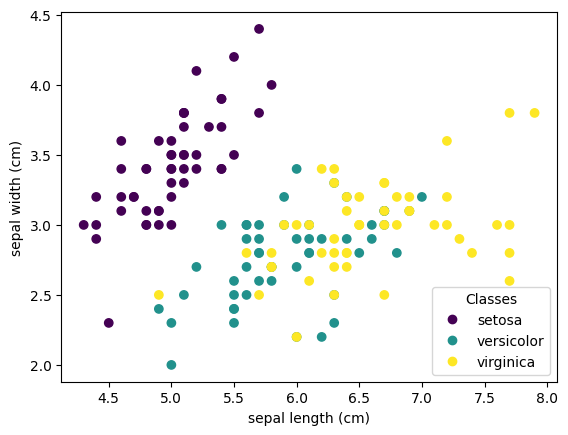

In [17]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

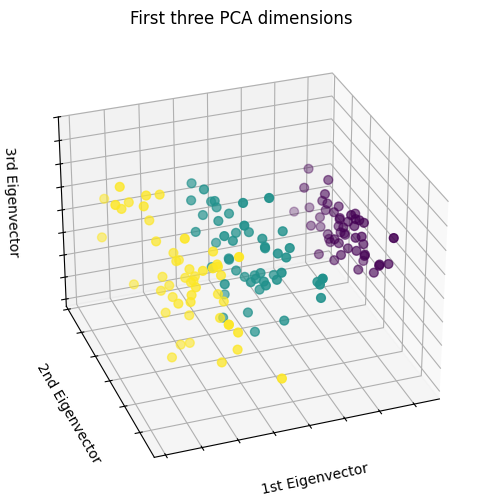

In [18]:
# unused but required import for doing 3d projections with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401

from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

X_reduced = PCA(n_components=3).fit_transform(iris.data)
ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=iris.target,
    s=40,
)

ax.set_title("First three PCA dimensions")
ax.set_xlabel("1st Eigenvector")
ax.xaxis.set_ticklabels([])
ax.set_ylabel("2nd Eigenvector")
ax.yaxis.set_ticklabels([])
ax.set_zlabel("3rd Eigenvector")
ax.zaxis.set_ticklabels([])

plt.show()

In [19]:
# Pipelines
pipelines = {
    'KNN':           Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())]),
    'Decision Tree': Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=42))]),
    'Random Forest': Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(n_estimators=100, random_state=42))]),
}


In [20]:
# Cross-validation 5 folds
results = {}
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X, y, cv=cv,
                            scoring=['accuracy', 'f1_macro'],
                            return_train_score=False)
    results[name] = {
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std':  scores['test_accuracy'].std(),
        'f1_mean':       scores['test_f1_macro'].mean(),
        'f1_std':        scores['test_f1_macro'].std(),
    }

print(f"{'Modèle':<20} {'Accuracy':>12} {'F1-macro':>12}")
print('-' * 46)
for name, r in results.items():
    print(f"{name:<20} {r['accuracy_mean']:.4f} ±{r['accuracy_std']:.4f}   {r['f1_mean']:.4f} ±{r['f1_std']:.4f}")

Modèle                   Accuracy     F1-macro
----------------------------------------------
KNN                  0.9733 ±0.0249   0.9733 ±0.0250
Decision Tree        0.9533 ±0.0340   0.9531 ±0.0341
Random Forest        0.9467 ±0.0267   0.9464 ±0.0268


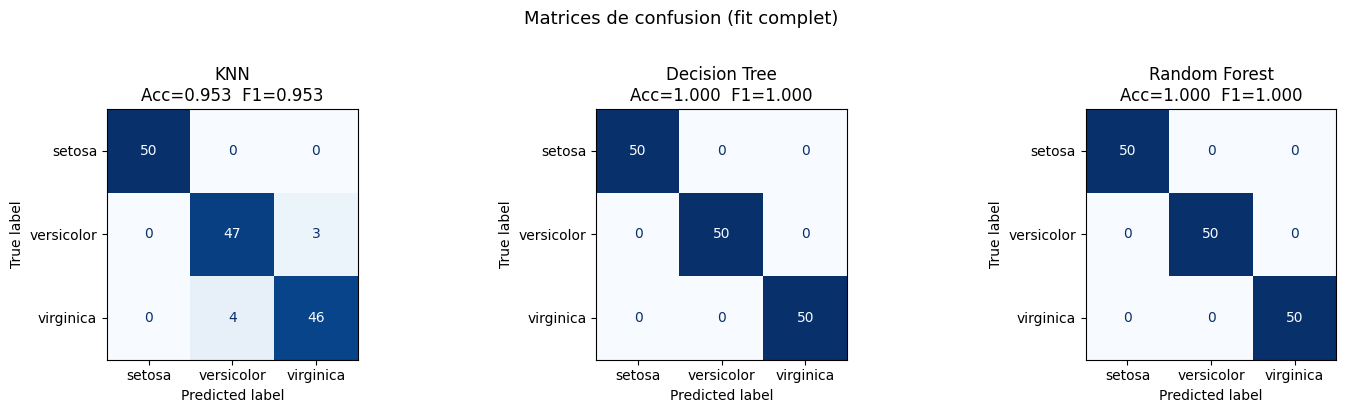

In [21]:
# Matrices de confusion (entraînement sur tout le dataset pour visualisation)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pipe) in zip(axes, pipelines.items()):
    pipe.fit(X, y)
    y_pred = pipe.predict(X)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={accuracy_score(y,y_pred):.3f}  F1={f1_score(y,y_pred,average="macro"):.3f}')

plt.suptitle('Matrices de confusion (fit complet)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

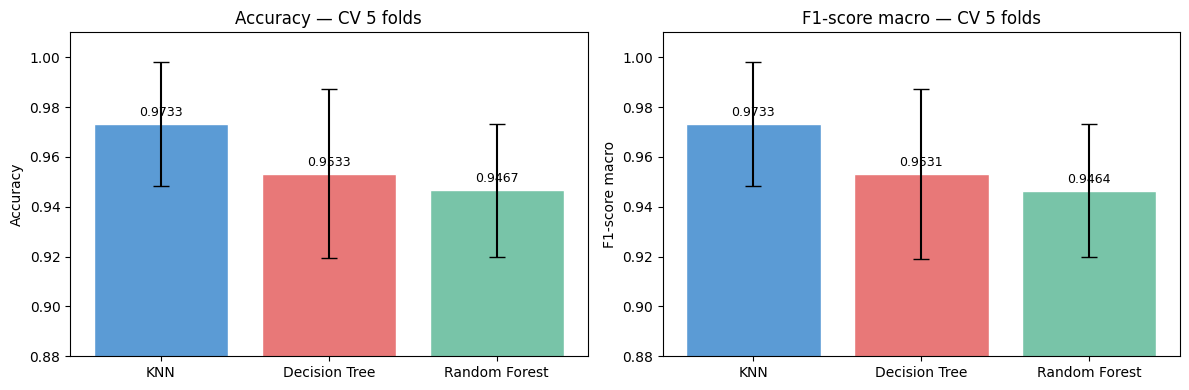

In [22]:
# Comparaison visuelle cross-validation
import pandas as pd

df_res = pd.DataFrame(results).T
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, label in zip(axes,
                              ['accuracy_mean', 'f1_mean'],
                              ['Accuracy', 'F1-score macro']):
    means = df_res[metric]
    stds  = df_res[metric.replace('mean', 'std')]
    bars  = ax.bar(means.index, means, yerr=stds, capsize=6,
                   color=['#5B9BD5','#E87878','#78C4A8'], edgecolor='white')
    ax.set_ylim(0.88, 1.01)
    ax.set_title(f'{label} — CV 5 folds')
    ax.set_ylabel(label)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
# Verdict
best = max(results, key=lambda k: results[k]['f1_mean'])
print(f"\n🏆 Meilleur modèle : {best}")
print(f"   F1-macro  : {results[best]['f1_mean']:.4f} ± {results[best]['f1_std']:.4f}")
print(f"   Accuracy  : {results[best]['accuracy_mean']:.4f} ± {results[best]['accuracy_std']:.4f}")

print("""
=== JUSTIFICATION ===

KNN          : bon sur Iris (données propres, faible dim.) mais sensible
               au scaling et coûteux à l'inférence sur grands datasets.

Decision Tree: interprétable, mais tend à overfitter — variance plus
               élevée visible dans l'écart-type CV.

Random Forest: ensemble de 100 arbres → variance réduite par bagging.
               Generalement meilleur F1 et accuracy les plus stables
               (écart-type le plus faible), ce qui en fait le choix
               le plus robuste pour un déploiement réel.
""")


🏆 Meilleur modèle : KNN
   F1-macro  : 0.9733 ± 0.0250
   Accuracy  : 0.9733 ± 0.0249

=== JUSTIFICATION ===

KNN          : bon sur Iris (données propres, faible dim.) mais sensible
               au scaling et coûteux à l'inférence sur grands datasets.

Decision Tree: interprétable, mais tend à overfitter — variance plus
               élevée visible dans l'écart-type CV.

Random Forest: ensemble de 100 arbres → variance réduite par bagging.
               Generalement meilleur F1 et accuracy les plus stables
               (écart-type le plus faible), ce qui en fait le choix
               le plus robuste pour un déploiement réel.

